## 1. Librerías y cargado del dataset


In [ ]:
# Librerías
from google.colab import drive
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Se carga el dataset
drive.mount('/content/drive')

ruta = '/content/drive/MyDrive/10ª Edición Máster en Data Science/TFM/clean_data_v1.csv'
df = pd.read_csv(ruta,encoding='Latin-1')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Se comprueba que está todo correcto con respecto al pretratado que se hizo de los datos (cantidad de datos, nulos, tipo de dato, número de variables...)
print("Dimensiones:", df.shape)
print(df["DIABETE3"].value_counts(normalize=True))
print(df.info())

Dimensiones: (257709, 23)
DIABETE3
3.0    0.889833
1.0    0.110167
Name: proportion, dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257709 entries, 0 to 257708
Data columns (total 23 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   GENHLTH   257709 non-null  float64
 1   BPHIGH4   257709 non-null  float64
 2   BPMEDS    257709 non-null  float64
 3   BLOODCHO  257709 non-null  float64
 4   HAVARTH3  257709 non-null  float64
 5   ADDEPEV2  257709 non-null  float64
 6   DIABETE3  257709 non-null  float64
 7   SEX       257709 non-null  float64
 8   QLACTLM2  257709 non-null  float64
 9   USEEQUIP  257709 non-null  float64
 10  BLIND     257709 non-null  float64
 11  DECIDE    257709 non-null  float64
 12  DIFFWALK  257709 non-null  float64
 13  DIFFDRES  257709 non-null  float64
 14  DIFFALON  257709 non-null  float64
 15  SMOKE100  257709 non-null  float64
 16  EXEROFT1  257709 non-null  float64
 17  _RACE     257709 non-nul

In [ ]:
# Se convierte a 0/1: 1 = diabético, 0 = no diabético. Se ponen los valores iniciales como float para que no de problemas a la hora de mapear
df['DIABETE3'] = df['DIABETE3'].map({1.0:1, 3.0:0})
df['DIABETE3'].value_counts()

,count
DIABETE3,
0,229318
1,28391


## 2. Exploración y entendimiento de los datos (EDA)

/tmp/ipython-input-954627708.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="DIABETE3", palette="Set2")


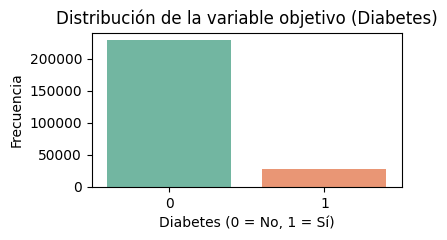

In [ ]:
# Se visualiza la distribución del target (desbalanceado)
plt.figure(figsize=(4,2))
sns.countplot(data=df, x="DIABETE3", palette="Set2")
plt.title("Distribución de la variable objetivo (Diabetes)")
plt.xlabel("Diabetes (0 = No, 1 = Sí)")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
# Se separan las variables en función de sus datos para ver las relaciones entre ellas
categoricas_nominales = ['BPHIGH4', 'BPMEDS', 'BLOODCHO', 'HAVARTH3', 'QLACTLM2', 'USEEQUIP', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES', 'DIFFALON', 'SMOKE100', 'ADDEPEV2', '_RACE', 'SEX'] # No siguen orden lógico, todas "valen" lo mismo
categoricas_ordinales = ['GENHLTH', '_PACAT1', '_AGEG5YR', '_BMI5CAT']
numericas = ['EXEROFT1', '_FRUTSUM', '_VEGESUM']
target = 'DIABETE3'

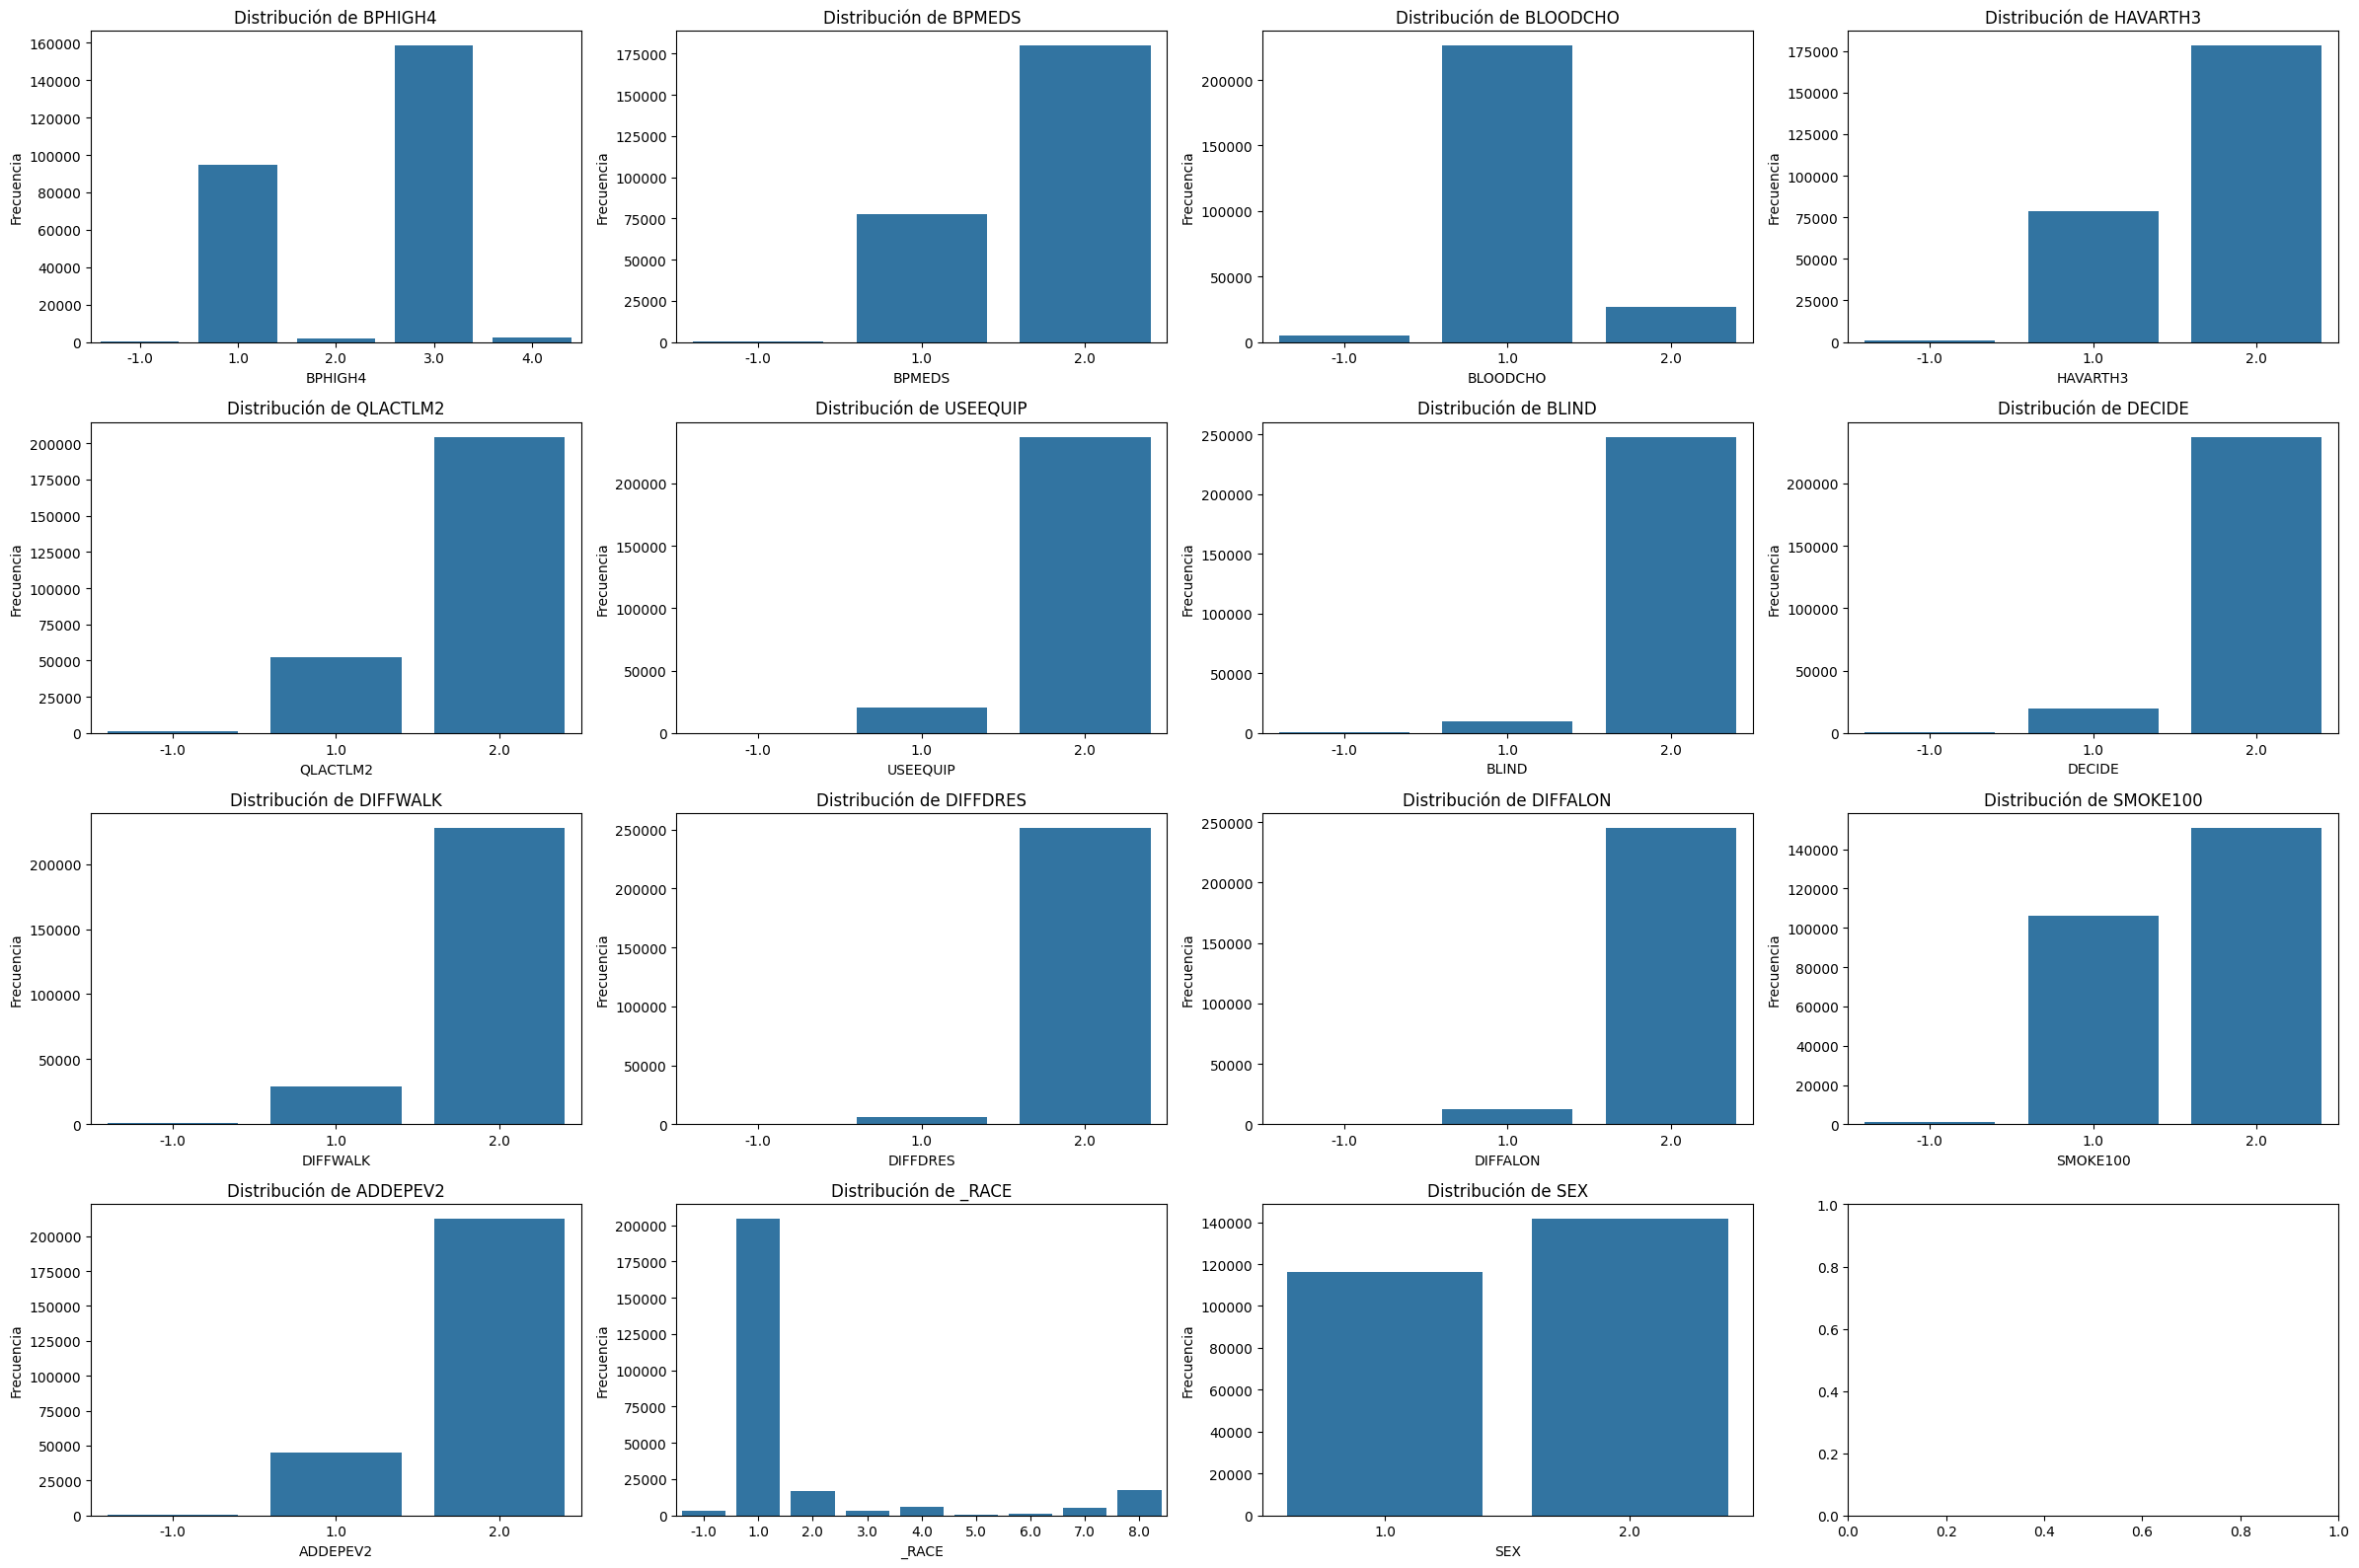

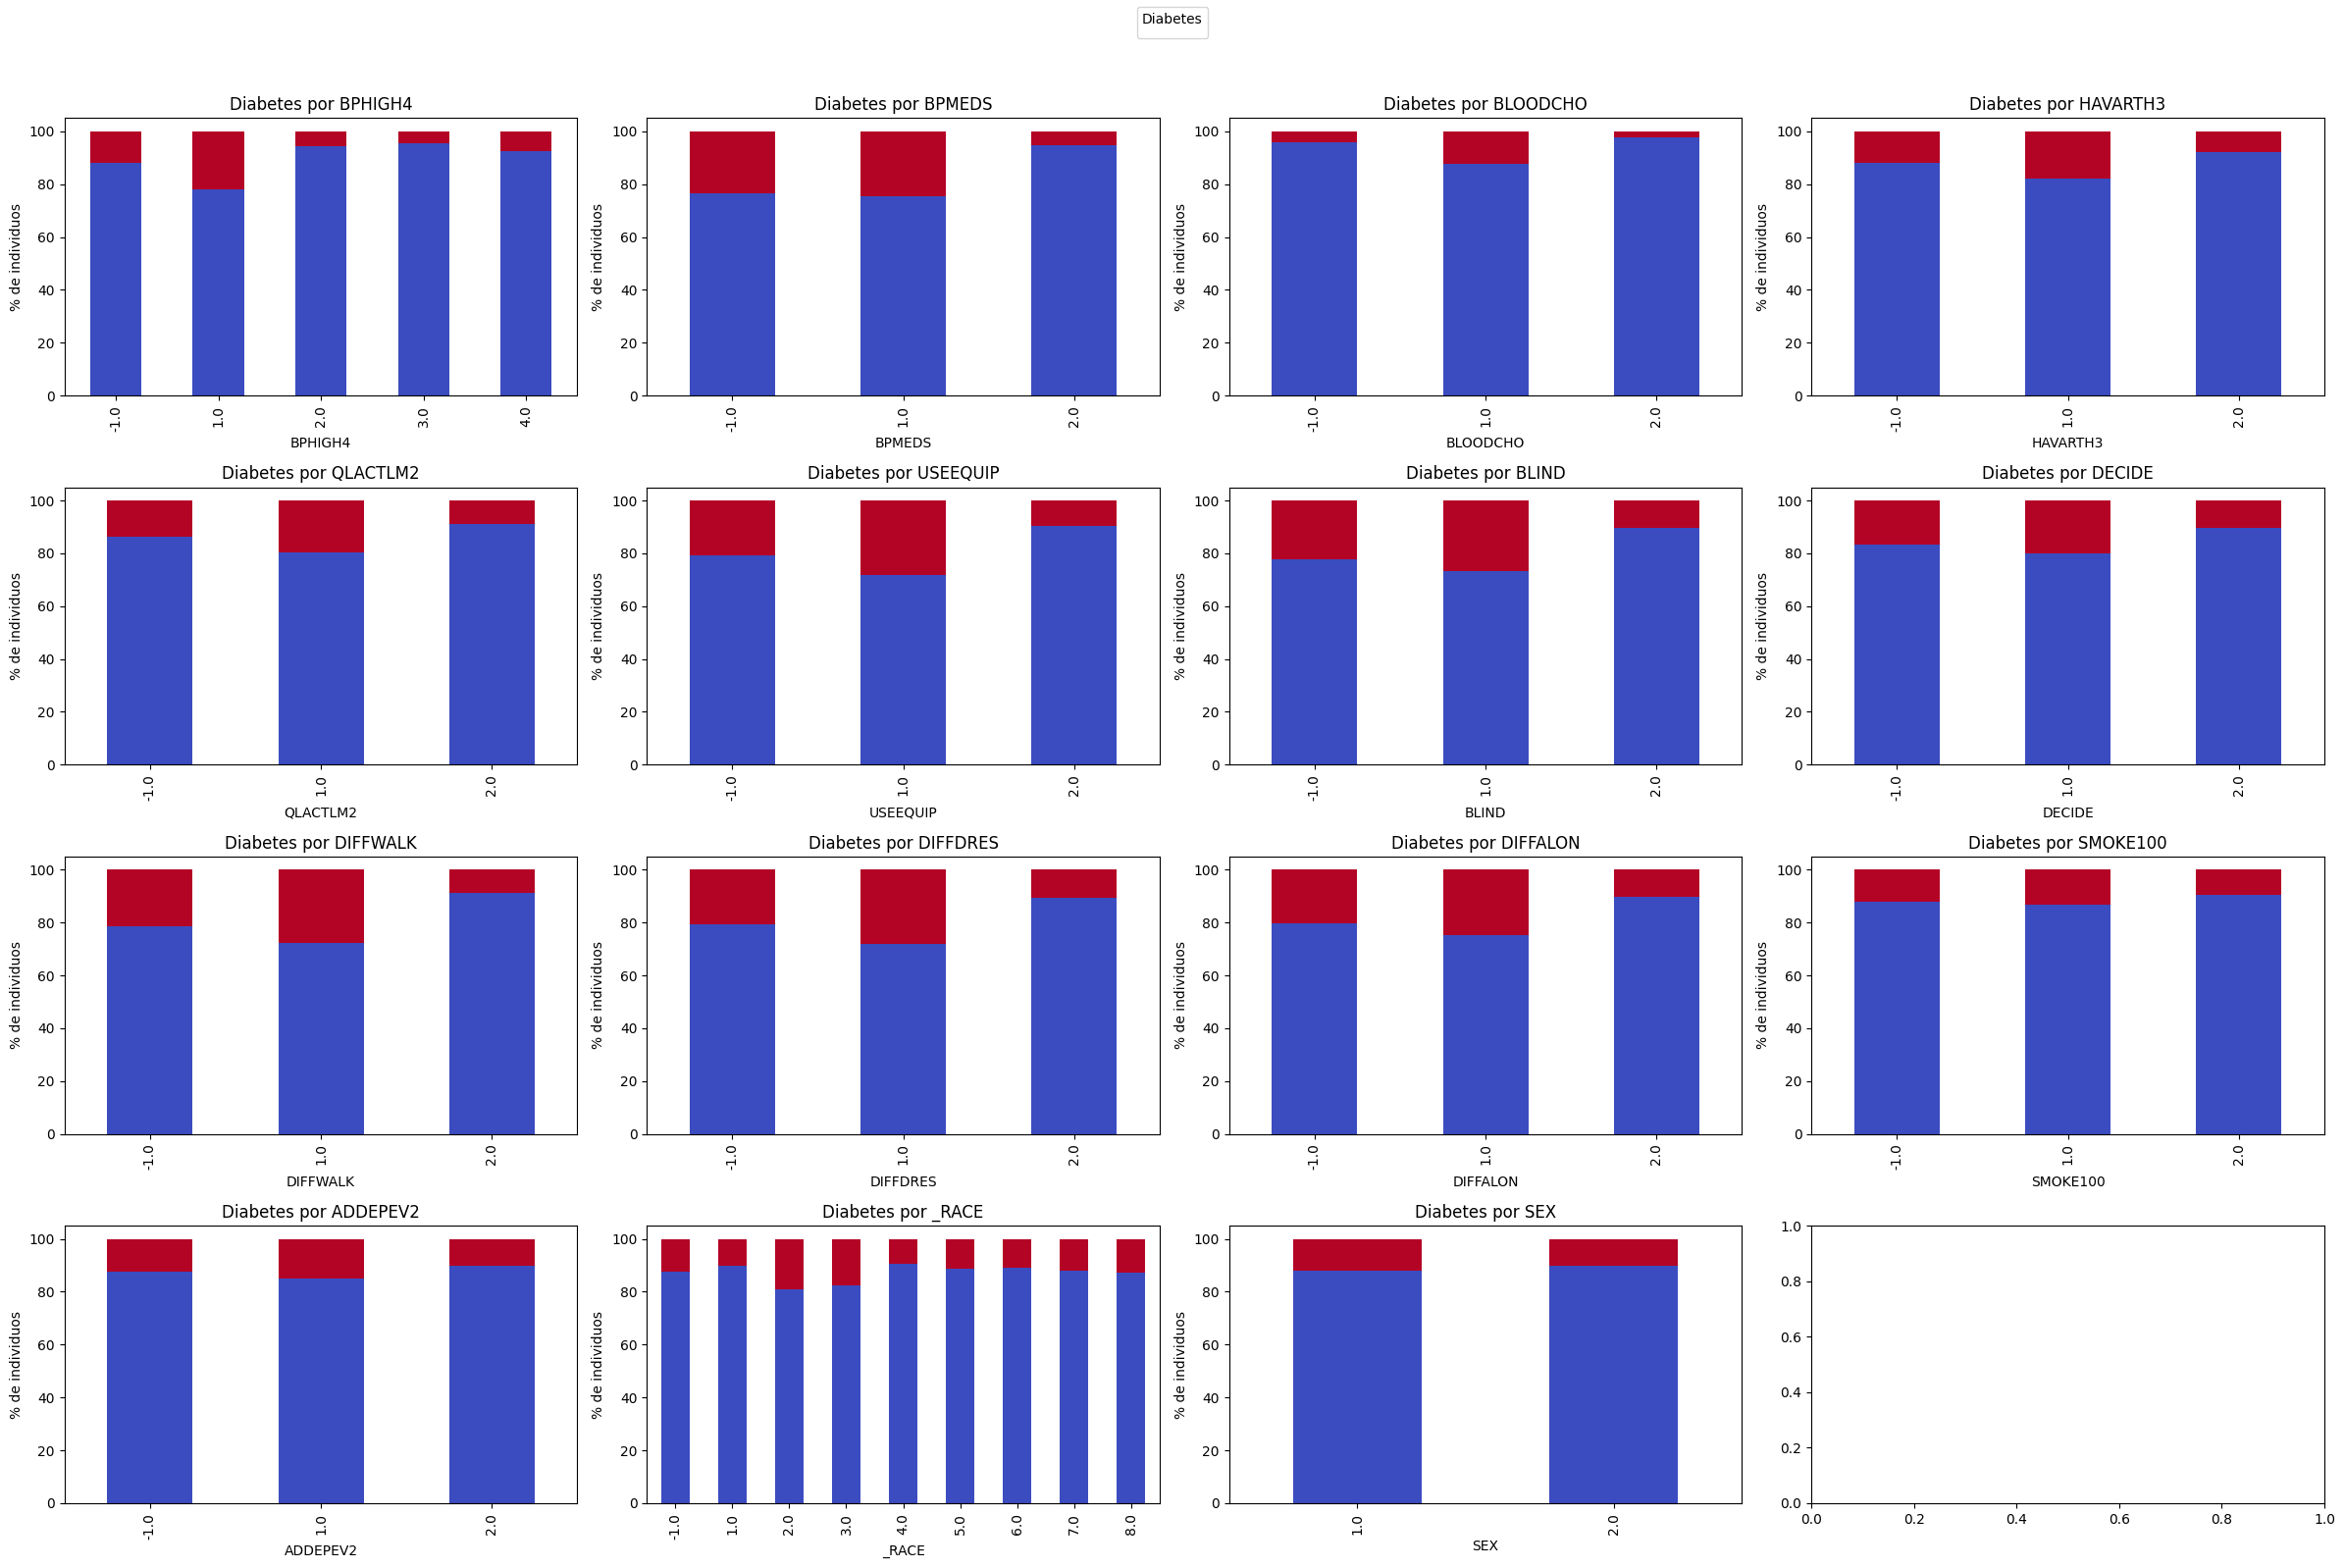

In [ ]:
# Variables categóricas nominales:
fig, axes = plt.subplots(4, 4, figsize=(24, 16))
axes = axes.flatten()
for i, col in enumerate(categoricas_nominales):
    sns.countplot(x=col, data=df, order=sorted(df[col].unique()), ax=axes[i])
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# Distribución del target en función de las clases
fig, axes = plt.subplots(4, 4, figsize=(24, 16))
axes = axes.flatten()
for i, col in enumerate(categoricas_nominales):
    prop = pd.crosstab(df[col], df[target], normalize='index') * 100
    prop.plot(kind='bar', stacked=True, colormap='coolwarm', ax=axes[i], legend=False)
    axes[i].set_title(f"Diabetes por {col}")
    axes[i].set_ylabel("% de individuos")
    axes[i].set_xlabel(col)

# Se añade una sola leyenda común
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, ['No', 'Sí'], title='Diabetes', loc='upper center', ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


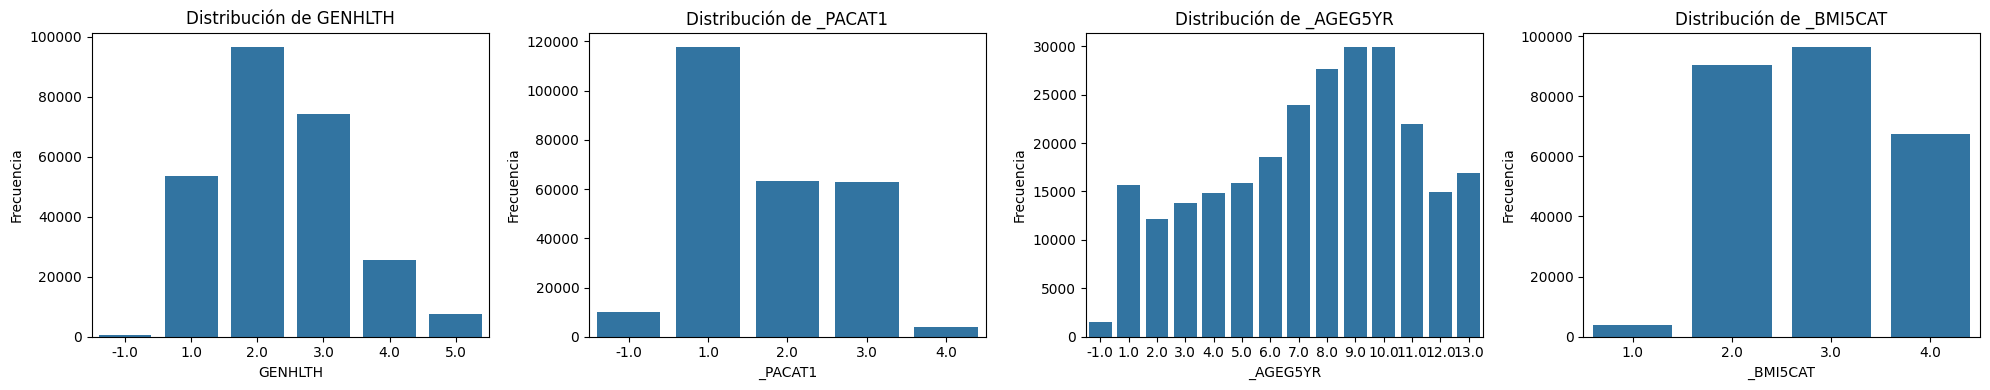

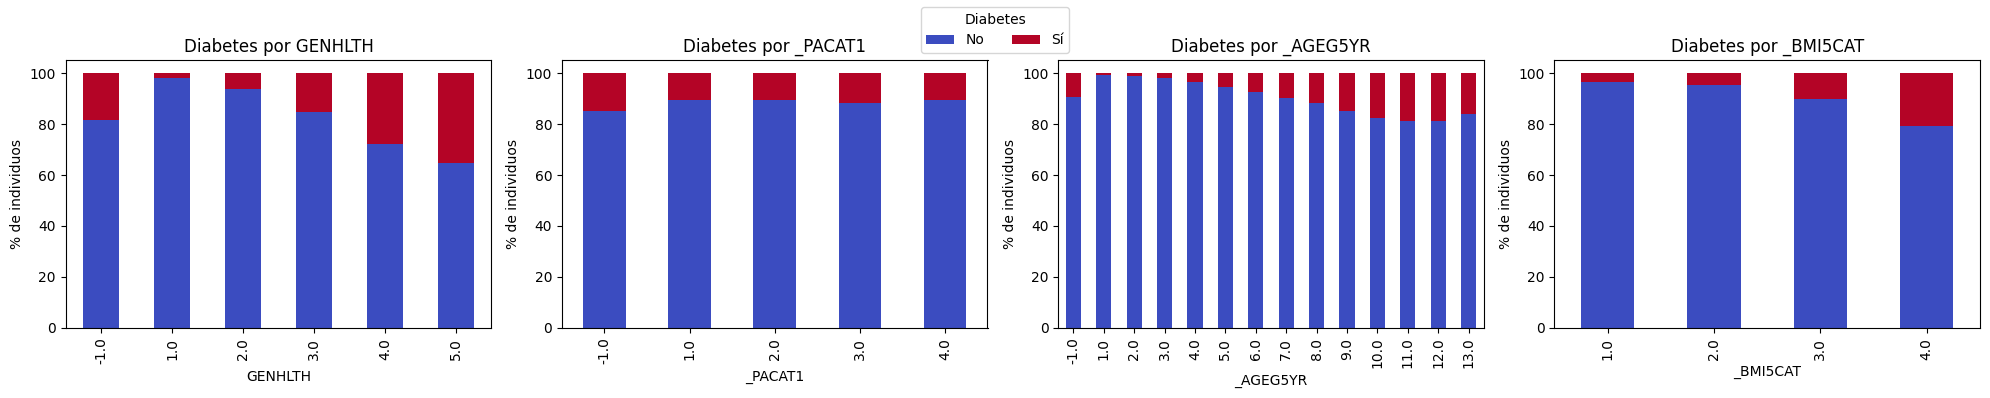

In [ ]:
# Variables categóricas ordinales:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, col in enumerate(categoricas_ordinales):
    sns.countplot(x=col, data=df, order=sorted(df[col].unique()), ax=axes[i])
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# Distribución del target en función de las clases
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, col in enumerate(categoricas_ordinales):
    prop = pd.crosstab(df[col], df[target], normalize='index') * 100
    prop.plot(kind='bar', stacked=True, colormap='coolwarm', ax=axes[i], legend=False)
    axes[i].set_title(f"Diabetes por {col}")
    axes[i].set_ylabel("% de individuos")
    axes[i].set_xlabel(col)

# Se añade una sola leyenda común
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, ['No', 'Sí'], title='Diabetes', loc='upper center', ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

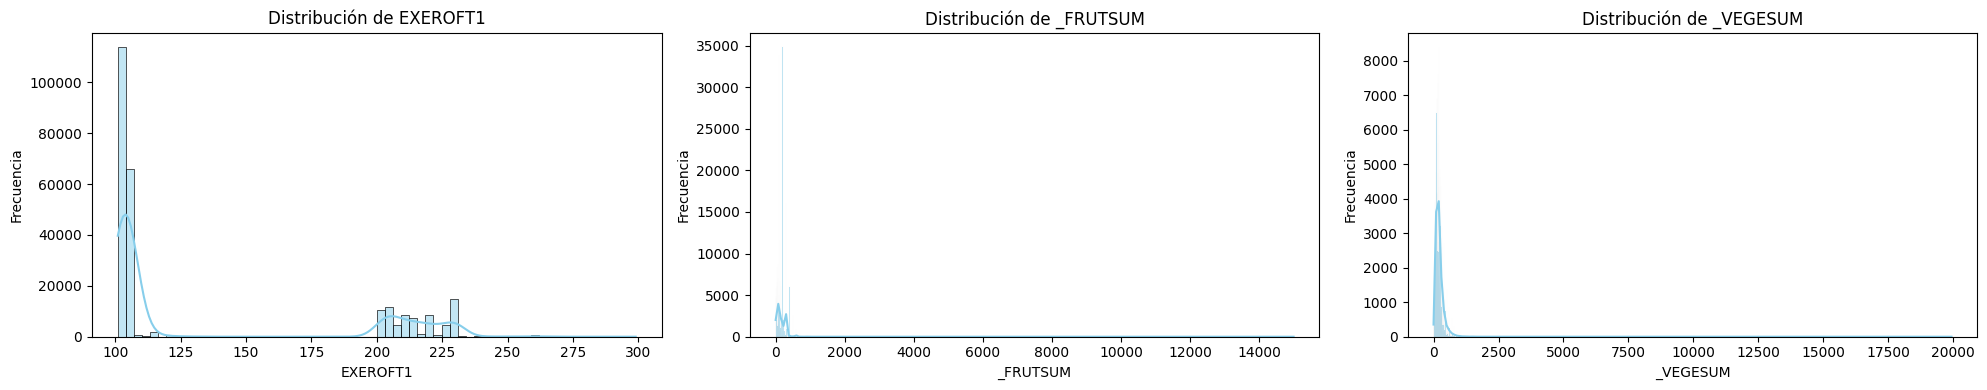

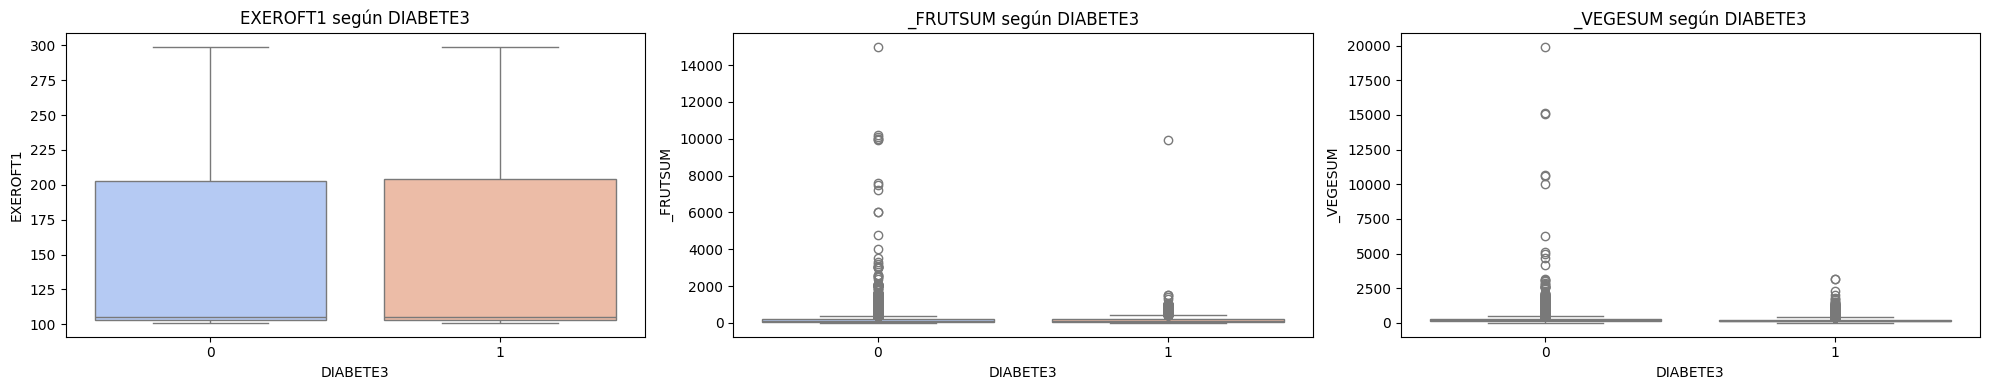

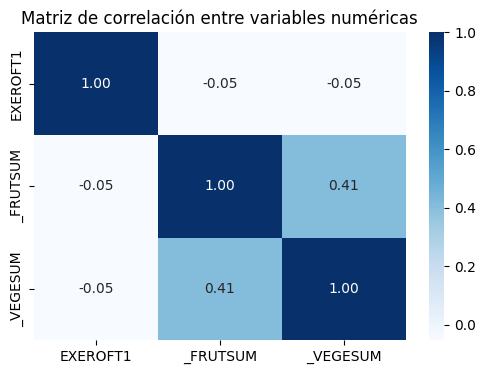

In [ ]:
# Variables numéricas:
# Histograma para observar: asimetría, sesgos, valores extremos...
fig, axes = plt.subplots(1, 3, figsize=(20, 4))
for i, col in enumerate(numericas):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# Boxplot: muestra cómo cambian las variables numéricas entre grupos (por ejemplo, personas con o sin diabetes)
fig, axes = plt.subplots(1, 3, figsize=(20, 4))
for i, col in enumerate(numericas):
    sns.boxplot(
        x=target,
        y=col,
        hue=target,
        data=df,
        ax=axes[i],
        palette='coolwarm',
        legend=False
    )
    axes[i].set_title(f"{col} según {target}")
    axes[i].set_xlabel(target)
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

# Heatmap: Permite ver si hay variables muy correlacionadas (redundantes) o independientes.
corr = df[numericas].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f")
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

## 3. División del dataset

In [ ]:
# Se divide separar el target del resto de variables del dataset
X = df.drop("DIABETE3", axis=1)
y = df["DIABETE3"]

In [ ]:
# Se realiza una separación de train 60/validation 20/test 20 - (temp 40, será solo temporal).
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Tamaños -> Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Tamaños -> Train: (154625, 22), Val: (51542, 22), Test: (51542, 22)


## 4. Preprocesamiento

In [ ]:
# Primera prueba no se balancea (EXPLICADO EN EL DOCUMENTO********)
# No se realiza: Escalado / normalización de variables numéricas ni selección o ingeniería de features

## 5. Pipeline y entrenamiento del modelo

In [ ]:
# Se hace la imputación para evitar problemas con la clase  (EXPLICADO EN EL DOCUMENTO**************)
# preprocessor = ColumnTransformer(
#     transformers=[
#         ("num", Pipeline([("imputer", SimpleImputer(strategy="mean")), ("scaler", StandardScaler())]), numerical),
#         ("cat_nom", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_nominal),
#         ("cat_ord", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("ordinal", OrdinalEncoder())]), categorical_ordinal)
#     ]
# )

In [ ]:
# Se definen los modelos base (PRIMERA PRUEBA OMITIMOS DE LA LISTA DE ARGUMENTOS: ("preprocessor", preprocessor) Y scale_pos_weight=scale_pos_weight -> XGB y class_weight=class_weights -> RL y RF)
models = {
    "Logistic Regression": Pipeline([("logreg", LogisticRegression(max_iter=1000, solver='liblinear'))]), #Solver para la funcion de perdida
    "Random Forest": Pipeline([("rf", RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42))]),
    "XGBoost": Pipeline([("xgb", XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5, eval_metric='logloss', random_state=42, n_jobs=-1))])
}

In [ ]:
# Funciones auxiliares
def entrenar_y_predecir(pipe, X_train, y_train, X_val, threshold=0.15):
    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_val)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    return y_pred, y_prob

def calcular_metricas(y_val, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1-score": f1_score(y_val, y_pred),
        "ROC-AUC": roc_auc_score(y_val, y_prob)
    }

def importancia_variables(pipe, X_train):
    # No sería necesario ponerlo [-1], solo hay un elemento en pipe porque no se aplicaron transformadores (ej cuando sí: dict_values([StandardScaler(), RandomForestClassifier()])). No dará error, solo 1 elemento en la lista
    modelo_final = list(pipe.named_steps.values())[-1]
    # hasattr: Verifica si tiene atributo o no. Devuelve TRUE o FALSE. feature_importances_ -> RF y XGB. Coeficientes (coef_) -> RL
    if hasattr(modelo_final, "feature_importances_"):
        importancias = modelo_final.feature_importances_
    elif hasattr(modelo_final, "coef_"):
        importancias = modelo_final.coef_[0]
    else:
        return None

    df_importancia = pd.DataFrame({
        "Variable": X_train.columns,
        "Importancia": importancias
    }).sort_values(by="Importancia", ascending=False)

    return df_importancia

In [ ]:
# Entrenamiento del modelo y cálculo de métricas
threshold = 0.15
results = []
importancias_modelos = {}

for name, pipe in models.items():

    y_pred, y_prob = entrenar_y_predecir(pipe, X_train, y_train, X_val, threshold)

    metricas = calcular_metricas(y_val, y_pred, y_prob)
    metricas["Modelo"] = name
    results.append(metricas)

    df_importancia = importancia_variables(pipe, X_train)
    importancias_modelos[name] = df_importancia

## 6. Evaluación del modelo

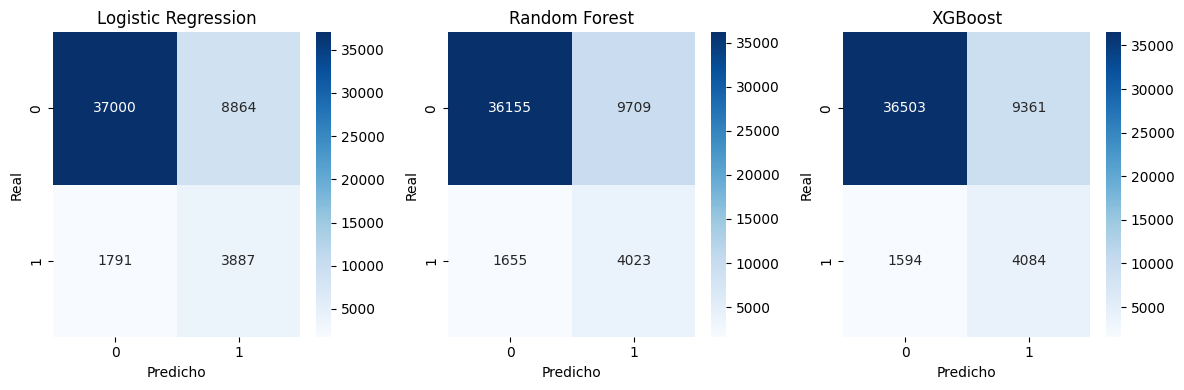

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (name, pipe) in zip(axes, models.items()):
    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_val)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=[0,1], yticklabels=[0,1], ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

In [ ]:
df_results = pd.DataFrame(results)

# Se muestran solo las columnas que interesan para el caso
display(df_results[["Modelo", "F1-score", "Recall"]])

#*************************************************
# El recall supera 0.7, lo cual es aceptable y clínicamente útil: el modelo detecta correctamente a más de 7 de cada 10 pacientes diabéticos.
# Ajustar scale_pos_weight (será necesario rebalancear el target) en XGBoost para penalizar más los falsos negativos.

,Modelo,F1-score,Recall
0,Logistic Regression,0.421835,0.684572
1,Random Forest,0.414529,0.708524
2,XGBoost,0.427130,0.719267


In [ ]:
# Se comprueba la importancia de las distintas variables en cada uno de los modelos
if importancias_modelos:
    for modelo, df in importancias_modelos.items():
        print(f"\nImportancia top 10 para {modelo}:")
        display(df.head(10))
else:
    print("No hay importancias para mostrar. Verifica que los modelos tengan atributos válidos y que el diccionario se llenó correctamente.")


Importancia top 10 para Logistic Regression:


,Variable,Importancia
18,_BMI5CAT,0.639553
0,GENHLTH,0.567222
17,_AGEG5YR,0.156018
12,DIFFDRES,0.140680
16,_RACE,0.067977
7,QLACTLM2,0.052655
4,HAVARTH3,0.039945
13,DIFFALON,0.017950
21,_PACAT1,0.009934
20,_VEGESUM,0.000070



Importancia top 10 para Random Forest:


,Variable,Importancia
2,BPMEDS,0.222474
0,GENHLTH,0.191916
1,BPHIGH4,0.152885
18,_BMI5CAT,0.118754
17,_AGEG5YR,0.080305
11,DIFFWALK,0.061793
8,USEEQUIP,0.031768
16,_RACE,0.021385
20,_VEGESUM,0.014879
4,HAVARTH3,0.013780



Importancia top 10 para XGBoost:


,Variable,Importancia
2,BPMEDS,0.551033
1,BPHIGH4,0.120700
0,GENHLTH,0.095197
18,_BMI5CAT,0.054915
17,_AGEG5YR,0.032112
3,BLOODCHO,0.026167
6,SEX,0.014912
8,USEEQUIP,0.013872
9,BLIND,0.013333
16,_RACE,0.012836
